In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max.columns',None)

In [4]:
df = pd.read_csv('../data/processed/gurgaon_property_cleaned.csv')

In [5]:
df['luxury_category'].unique()

array(['Unfurnished', 'Basic', 'Premium', 'Luxury', 'Semi-Luxury'],
      dtype=object)

In [5]:
df.drop(columns=['build_up','society' , 'area_type' , 'area_sqm' , 'area_unit' , 'Unnamed: 0.1' ,'Unnamed: 0' ] , inplace=True)

In [6]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,additionalRoom,agePossession,built_up_area,luxury_category,bhk,floor_cat
0,flat,sector 49,0.35,2,2,2,not_available,0-1 Years Old,616.0,Unfurnished,2,higher
1,flat,sector 49,0.38,2,2,2,not_available,1-5 Years Old,750.0,Basic,2,higher
2,flat,sector 92,0.49,2,2,2,not_available,1-5 Years Old,1109.0,Unfurnished,2,lower
3,flat,sector 89,0.80,2,3,3,"study room,others",Under Construction,1660.0,Unfurnished,2,middle
4,flat,sector 49,1.55,3,2,3+,not_available,Upcoming,1730.0,Unfurnished,3,middle


In [7]:
df.shape

(3215, 12)

##  ordinal encoding

In [8]:
from sklearn.preprocessing import OrdinalEncoder

In [9]:
# Create a copy of the original data for label encoding
data_label_encoded = df.copy()

In [10]:
categorical_col = data_label_encoded.select_dtypes(include=['object']).columns

In [11]:
# apply ordinal encoding on copy data set
for col in categorical_col:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)


x_label = data_label_encoded.drop(columns='price')  
y_label = data_label_encoded['price']  

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 2', 'sector 21', 'sector 22', 'sector 23', 'sector 24',
       'sector 25', 'sector 26', 'sector 28', 'sector 3', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 49 road',
       'sector 5', 'sector 50', 'sector 51', 'sector 52', 'sector 53',
       'sector 54', 'sector 55', 'sector 56', 'sector 57', 'sector 58',
       

In [12]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,additionalRoom,agePossession,built_up_area,luxury_category,bhk,floor_cat
0,0.0,52.0,2,2,2.0,1.0,0.0,616.0,4.0,2,0.0
1,0.0,52.0,2,2,2.0,1.0,1.0,750.0,0.0,2,0.0
2,0.0,101.0,2,2,2.0,1.0,1.0,1109.0,4.0,2,1.0
3,0.0,97.0,2,3,3.0,44.0,5.0,1660.0,4.0,2,2.0
4,0.0,52.0,3,2,4.0,1.0,7.0,1730.0,4.0,3,2.0
...,...,...,...,...,...,...,...,...,...,...,...
3210,0.0,13.0,3,4,3.0,21.0,1.0,1860.0,2.0,3,2.0
3211,0.0,68.0,4,4,4.0,7.0,1.0,4200.0,2.0,4,0.0
3212,0.0,36.0,3,2,3.0,1.0,5.0,1081.0,4.0,3,1.0
3213,0.0,86.0,2,2,2.0,53.0,1.0,1556.0,2.0,2,1.0


In [13]:
y_label

0       0.35
1       0.38
2       0.49
3       0.80
4       1.55
        ... 
3210    2.20
3211    7.56
3212    0.72
3213    1.40
3214    2.34
Name: price, Length: 3215, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

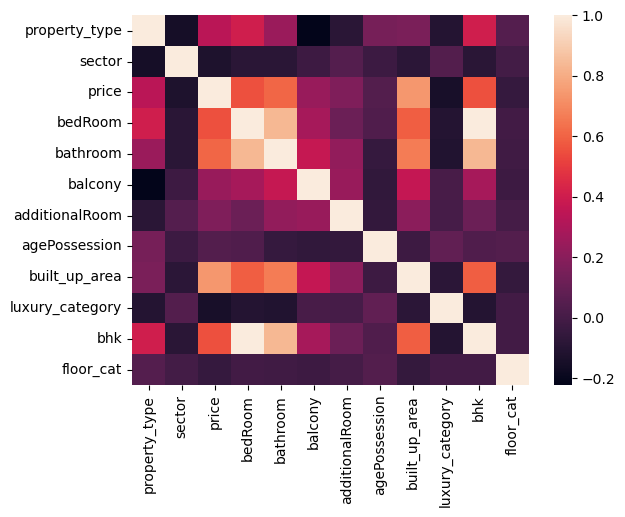

In [14]:
sns.heatmap(data_label_encoded.corr())

In [15]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.123457
1,price,1.000000
2,bedRoom,0.555109
3,bathroom,0.607622
4,balcony,0.243476
5,additionalRoom,0.169343
6,agePossession,0.039812
7,built_up_area,0.738812
8,luxury_category,-0.143031
9,bhk,0.555109


### Technique 2 - Random Forest Feature Importance

In [16]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200 , random_state=42 , n_jobs=-1)
rf.fit(x_label , y_label)
fi_df2 = pd.DataFrame({
    'feature': x_label.columns,
    'rf_importance': rf.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.630430
1,sector,0.136616
3,bathroom,0.067317
0,property_type,0.040125
5,additionalRoom,0.037426
4,balcony,0.019706
8,luxury_category,0.016485
6,agePossession,0.016442
2,bedRoom,0.014783
9,bhk,0.012446


In [17]:
x_label.isnull().sum()

property_type      0
sector             0
bedRoom            0
bathroom           0
balcony            0
additionalRoom     0
agePossession      0
built_up_area      0
luxury_category    0
bhk                0
floor_cat          0
dtype: int64

### Technique 3 - Gradient Boosting Feature importances

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(x_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': x_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.691187
1,sector,0.136318
3,bathroom,0.064365
0,property_type,0.046116
5,additionalRoom,0.024474
9,bhk,0.010323
8,luxury_category,0.007787
2,bedRoom,0.006897
4,balcony,0.005865
6,agePossession,0.004906


### Technique 4 - Permutation Importance

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
rf = RandomForestRegressor(
    n_estimators=   200,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_label,y_label)


result = permutation_importance(
    rf,
    x_label,
    y_label,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

importance = pd.DataFrame({
    'feature':x_label.columns,
    'importance':result.importances_mean
})

fi_df4 = perimportance.sort_values(
    by='importance',
    ascending=False
)

fi_df4

NameError: name 'perimportance' is not defined

### Technique 5 - LASSO

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_label)
X_test_scaled = scaler.transform(x_label)


lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_label)

fi_df5 = pd.DataFrame({
    'feature': x_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
7,built_up_area,1.113192
0,property_type,0.372875
3,bathroom,0.287642
6,agePossession,0.065264
5,additionalRoom,0.056084
4,balcony,0.011777
2,bedRoom,-0.000000
9,bhk,-0.017897
10,floor_cat,-0.036214
1,sector,-0.046730


### Technique 6 - RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rf,
    n_features_to_select=10,
    step=1
)

rfe = rfe.fit(x_label,y_label)

selected_features = x_label.columns[rfe.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = rfe.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
7,built_up_area,0.632509
1,sector,0.138448
3,bathroom,0.068521
0,property_type,0.043128
5,additionalRoom,0.036021
4,balcony,0.019593
6,agePossession,0.017920
8,luxury_category,0.015749
9,bhk,0.014175
2,bedRoom,0.013935


### Technique 8 - SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

fi_df8 = pd.DataFrame({
    'feature': x_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,0.790598
1,sector,0.338500
3,bathroom,0.244249
0,property_type,0.108350
5,additionalRoom,0.045614
4,balcony,0.029402
8,luxury_category,0.027635
6,agePossession,0.026651
10,floor_cat,0.022651
2,bedRoom,0.017534


In [ ]:

final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [ ]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,importance,lasso_coeff,rfe_score,SHAP_score
feature,,,,,,,
sector,-0.123457,0.136616,0.135987,0.305664,-0.046730,0.138448,0.338500
bedRoom,0.555109,0.014783,0.005803,0.015941,-0.000000,0.013935,0.017534
bathroom,0.607622,0.067317,0.064605,0.227771,0.287642,0.068521,0.244249
balcony,0.243476,0.019706,0.006611,0.032429,0.011777,0.019593,0.029402
additionalRoom,0.169343,0.037426,0.024332,0.050397,0.056084,0.036021,0.045614
agePossession,0.039812,0.016442,0.004662,0.017699,0.065264,0.017920,0.026651
built_up_area,0.738812,0.630430,0.691145,0.937219,1.113192,0.632509,0.790598
luxury_category,-0.143031,0.016485,0.011357,0.017931,-0.103133,0.015749,0.027635
bhk,0.555109,0.012446,0.007620,0.013104,-0.017897,0.014175,0.014293


In [ ]:
final_fi_df[['rf_importance','gb_importance','importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.736380
sector             0.211043
bathroom           0.134493
additionalRoom     0.038758
balcony            0.021548
luxury_category    0.017832
agePossession      0.016675
bedRoom            0.013599
bhk                0.012328
dtype: float64

In [ ]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label, y_label, cv=5, scoring='r2')
scores.mean()

np.float64(0.7502564356016629)

In [20]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,additionalRoom,agePossession,built_up_area,luxury_category,bhk,floor_cat
0,flat,sector 49,0.35,2,2,2,not_available,0-1 Years Old,616.0,Unfurnished,2,higher
1,flat,sector 49,0.38,2,2,2,not_available,1-5 Years Old,750.0,Basic,2,higher
2,flat,sector 92,0.49,2,2,2,not_available,1-5 Years Old,1109.0,Unfurnished,2,lower
3,flat,sector 89,0.80,2,3,3,"study room,others",Under Construction,1660.0,Unfurnished,2,middle
4,flat,sector 49,1.55,3,2,3+,not_available,Upcoming,1730.0,Unfurnished,3,middle


In [21]:
df.to_csv('../data/processed/final_data_set.csv')